# Notebook 03: Model Training and Evaluation

This notebook trains three different models (Logistic Regression, Random Forest, and XGBoost), evaluates them on several metrics, plots a Precision-Recall curve, and exports the best model.

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_curve
)

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Preprocessor and Splits

In [2]:
X_train, X_test, y_train, y_test = joblib.load('../data/split_data.pkl')
preprocessor = joblib.load('../models/preprocessor.pkl')

## 2. Train Models

We build Pipelines for all three classifiers, integrating the preprocessor. To handle target imbalance, we use `class_weight='balanced'` for Logistic Regression and Random Forest, and compute `scale_pos_weight` for XGBoost.

In [3]:
# Calculate scale_pos_weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Computed XGBoost scale_pos_weight: {scale_pos_weight:.2f}')

# Define Pipelines
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'))
    ])
}

# Fit all models
for name, pipeline in models.items():
    print(f'Training {name}...')
    pipeline.fit(X_train, y_train)

Computed XGBoost scale_pos_weight: 2.77
Training Logistic Regression...
Training Random Forest...


Training XGBoost...


## 3. Evaluate Model Performance

We evaluate Accuracy, ROC-AUC, F1-Score, Precision, and Recall for each model, and print confusion matrices and classification reports.

MODEL: Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



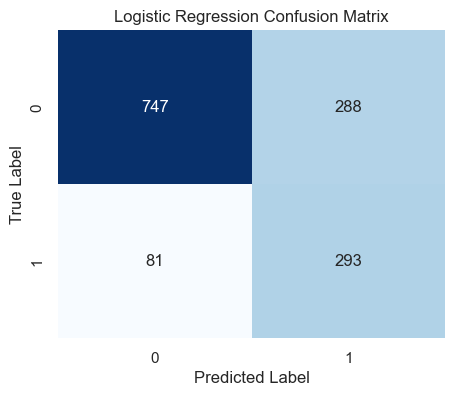

MODEL: Random Forest
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.54      0.64      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409



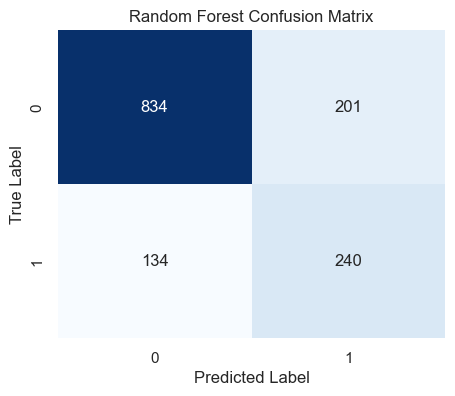

MODEL: XGBoost
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.53      0.70      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.76      0.77      1409



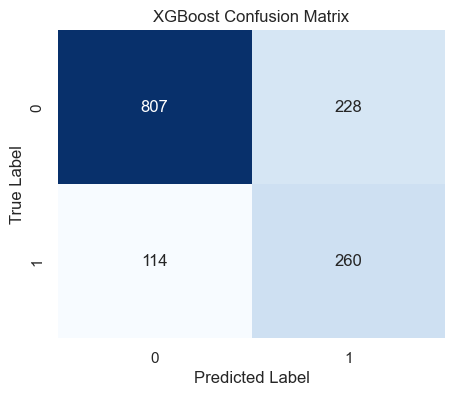

Summary Table:
                     Accuracy  ROC-AUC  F1 Score  Precision  Recall
Model                                                              
Logistic Regression     0.738    0.842     0.614      0.504   0.783
Random Forest           0.762    0.823     0.589      0.544   0.642
XGBoost                 0.757    0.819     0.603      0.533   0.695


In [4]:
metrics_summary = []

for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_probs),
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    }
    metrics_summary.append(metrics)
    
    print('='*50)
    print(f'MODEL: {name}')
    print('='*50)
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.show()

df_metrics = pd.DataFrame(metrics_summary)
df_metrics.set_index('Model', inplace=True)
print('Summary Table:')
print(df_metrics.round(3))

## 4. Precision-Recall Curve & Threshold Optimization

We plot the Precision-Recall curve for each model. This allows us to select a threshold that balances false positives (precision) and false negatives (recall) according to our business preferences.

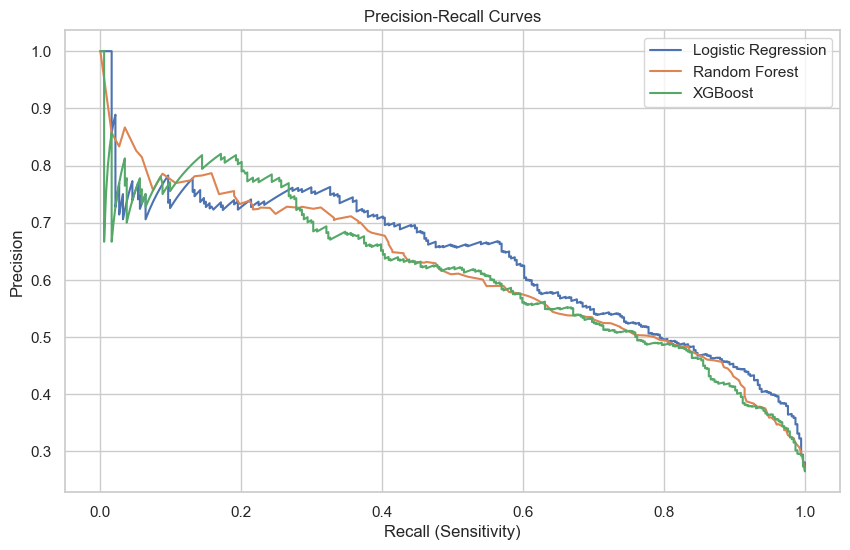

In [5]:
for name, pipeline in models.items():
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
    plt.plot(recalls, precisions, label=name)

plt.title('Precision-Recall Curves')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.legend()
plt.show()

## 5. Export the Best Performing Model

We inspect which model has the highest overall ROC-AUC / F1-Score, and save it as `models/best_model.pkl`.

In [6]:
# Identify model with highest ROC-AUC
best_model_name = df_metrics['ROC-AUC'].idxmax()
best_pipeline = models[best_model_name]
print(f'Saving best model: {best_model_name} (ROC-AUC: {df_metrics.loc[best_model_name, "ROC-AUC"]:.3f})')

os.makedirs('../models', exist_ok=True)
joblib.dump(best_pipeline, '../models/best_model.pkl')
print('Successfully saved models/best_model.pkl')

Saving best model: Logistic Regression (ROC-AUC: 0.842)
Successfully saved models/best_model.pkl
